# Stage 7 — Qualitative failure-case analysis

This notebook inspects errors and disagreements among the handcrafted baseline, frozen ResNet18, and fine-tuned ResNet18 on the **locked 4,050-image EuroSAT RGB test split**. It joins saved predictions by `dataset_index` and displays original 64 × 64 image patches. This is an explanatory review of already evaluated models; the test images must not be used to change labels, architecture, hyperparameters, or calibration.

The selected galleries combine six preselected cases from PermanentCrop, River, and Highway with the six most confident remaining fine-tuned errors and six most confident remaining corrections of frozen-model errors. The galleries are **purposefully selected examples**, not a random or representative sample of all errors. The complete fine-tuned error table is saved separately.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

ROOT = Path(r"C:\Users\comviva\Documents\Eurosat_calibrated")
IMAGE_ROOT = ROOT / "data" / "raw"
OUTPUT = ROOT / "results" / "qualitative_failure_analysis"
OUTPUT.mkdir(parents=True, exist_ok=True)

MANIFEST = ROOT / "data" / "splits" / "test.csv"

PREDICTION_FILES = {
    "handcrafted": ROOT / "results" / "statistical_baseline" / "test_predictions.csv",
    "frozen": ROOT / "results" / "frozen_resnet18" / "test_predictions.csv",
    "fine_tuned": ROOT / "results" / "fine_tuned_resnet18" / "test_predictions.csv",
}

for path in [MANIFEST, *PREDICTION_FILES.values()]:
    if not path.is_file():
        raise FileNotFoundError(path)

print("Reading project from:", ROOT)

Reading project from: C:\Users\comviva\Documents\Eurosat_calibrated


## Align predictions to the fixed test manifest

The image index is the pairing key. The code checks that each prediction file contains the same 4,050 unique test indices before comparing outcomes. A prediction is counted as correct when its class index matches the manifest label.


In [2]:
cases = pd.read_csv(MANIFEST)[
    ["dataset_index", "relative_path", "class_name", "class_index"]
].copy()

if len(cases) != 4050 or cases["dataset_index"].duplicated().any():
    raise ValueError("Expected the locked 4,050-image test manifest.")

def prediction_columns(path, model_name):
    table = pd.read_csv(path)

    if table["dataset_index"].duplicated().any():
        raise ValueError(f"Duplicate dataset indices in {path}")
    if set(table["dataset_index"]) != set(cases["dataset_index"]):
        raise ValueError(f"Test images in {path} do not match the manifest")

    return table[
        ["dataset_index", "predicted_class_index",
         "predicted_class_name", "confidence"]
    ].rename(columns={
        "predicted_class_index": f"{model_name}_index",
        "predicted_class_name": f"{model_name}_prediction",
        "confidence": f"{model_name}_confidence",
    })

for model_name, path in PREDICTION_FILES.items():
    cases = cases.merge(
        prediction_columns(path, model_name),
        on="dataset_index",
        how="left",
        validate="one_to_one",
    )
    cases[f"{model_name}_correct"] = (
        cases[f"{model_name}_index"] == cases["class_index"]
    )

def comparison_category(row):
    frozen_correct = row["frozen_correct"]
    fine_tuned_correct = row["fine_tuned_correct"]

    if not frozen_correct and fine_tuned_correct:
        return "corrected_by_fine_tuning"
    if frozen_correct and not fine_tuned_correct:
        return "new_error_after_fine_tuning"
    if not frozen_correct and not fine_tuned_correct:
        return "both_wrong"
    return "both_correct"

cases["comparison_category"] = cases.apply(comparison_category, axis=1)
cases["fine_tuned_error"] = ~cases["fine_tuned_correct"]

display(cases["comparison_category"].value_counts())
print("Fine-tuned errors:", cases["fine_tuned_error"].sum())

comparison_category
both_correct                   3815
corrected_by_fine_tuning        152
both_wrong                       53
new_error_after_fine_tuning      30
Name: count, dtype: int64

Fine-tuned errors: 83


## Count errors before inspecting examples

Counts across the complete test split provide context for the selected galleries. Error rates use each class's test-set size as their denominator. Confusion-pair counts describe the true class and the fine-tuned model's predicted class; they do not, by themselves, explain the visual cause of an error.


In [3]:
errors_by_class = (
    cases.groupby("class_name", as_index=False)
    .agg(
        test_images=("dataset_index", "size"),
        fine_tuned_errors=("fine_tuned_error", "sum"),
    )
)
errors_by_class["error_rate"] = (
    errors_by_class["fine_tuned_errors"]
    / errors_by_class["test_images"]
)
errors_by_class = errors_by_class.sort_values(
    "fine_tuned_errors", ascending=False
)

confusion_pairs = (
    cases.loc[cases["fine_tuned_error"]]
    .groupby(["class_name", "fine_tuned_prediction"])
    .size()
    .reset_index(name="images")
    .sort_values("images", ascending=False)
)

display(errors_by_class)
display(confusion_pairs.head(15))

errors_by_class.to_csv(OUTPUT / "errors_by_class.csv", index=False)
confusion_pairs.to_csv(OUTPUT / "fine_tuned_confusion_pairs.csv", index=False)
cases.loc[cases["fine_tuned_error"]].to_csv(
    OUTPUT / "all_fine_tuned_errors.csv", index=False
)

,class_name,test_images,fine_tuned_errors,error_rate
6,PermanentCrop,375,21,0.056000
5,Pasture,300,16,0.053333
2,HerbaceousVegetation,450,13,0.028889
8,River,375,11,0.029333
0,AnnualCrop,450,8,0.017778
3,Highway,375,8,0.021333
7,Residential,450,4,0.008889
4,Industrial,375,2,0.005333
1,Forest,450,0,0.000000
9,SeaLake,450,0,0.000000


,class_name,fine_tuned_prediction,images
22,PermanentCrop,AnnualCrop,11
17,Pasture,AnnualCrop,7
23,PermanentCrop,HerbaceousVegetation,6
18,Pasture,Forest,5
30,River,Highway,5
5,HerbaceousVegetation,Pasture,5
1,AnnualCrop,PermanentCrop,5
27,Residential,Industrial,4
28,River,AnnualCrop,3
6,HerbaceousVegetation,PermanentCrop,3


## Display preselected class examples

For each of PermanentCrop, River, and Highway, the first image was corrected by fine-tuning and the second remains incorrectly classified. The titles show each model's top-label confidence rounded to two decimals. A displayed `1.00` is a rounded probability, not certainty.


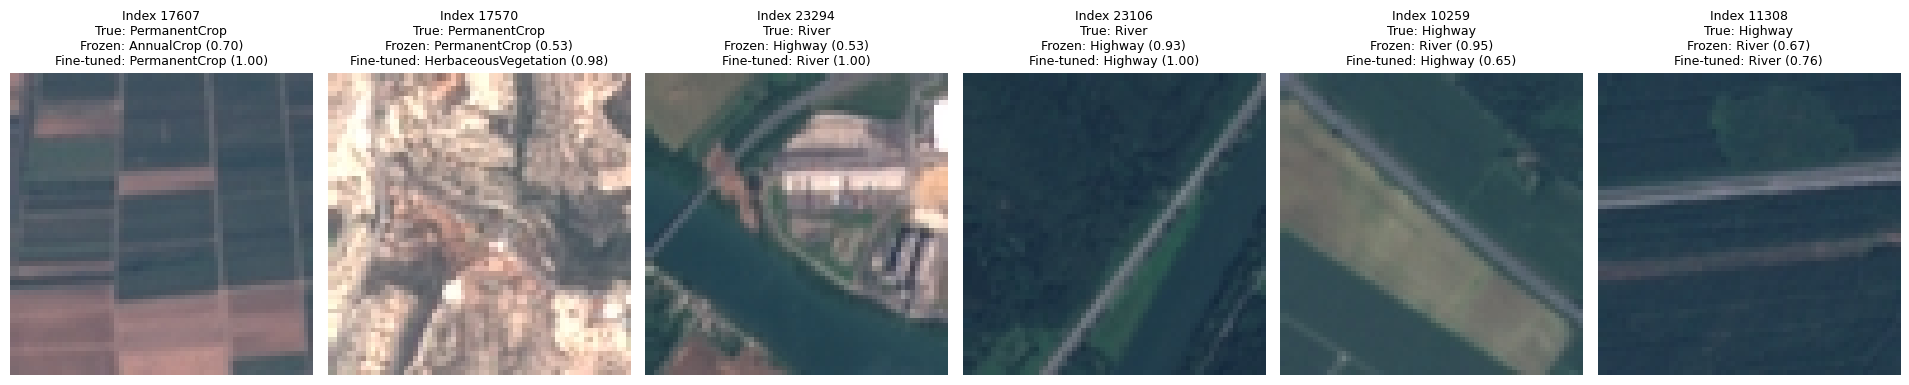

In [4]:
STARTER_IDS = [17607, 17570, 23294, 23106, 10259, 11308]

def image_path(relative_path):
    path = IMAGE_ROOT / Path(relative_path)
    if not path.is_file():
        raise FileNotFoundError(path)
    return path

def show_cases(dataset_indices, save_as=None):
    selected = cases.set_index("dataset_index").loc[dataset_indices]
    n = len(selected)

    fig, axes = plt.subplots(
        1, n, figsize=(3.2 * n, 4.2),
        squeeze=False,
    )

    for ax, (dataset_index, row) in zip(axes[0], selected.iterrows()):
        with Image.open(image_path(row["relative_path"])) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            f"Index {dataset_index}\n"
            f"True: {row['class_name']}\n"
            f"Frozen: {row['frozen_prediction']} "
            f"({row['frozen_confidence']:.2f})\n"
            f"Fine-tuned: {row['fine_tuned_prediction']} "
            f"({row['fine_tuned_confidence']:.2f})",
            fontsize=9,
        )
        ax.axis("off")

    fig.tight_layout()

    if save_as:
        fig.savefig(OUTPUT / save_as, dpi=180, bbox_inches="tight")

    plt.show()

show_cases(STARTER_IDS, "starter_cases.png")

## Display high-confidence errors and corrections

The next two galleries are ranked by the fine-tuned model's confidence. This deliberately emphasizes striking cases, so their apparent ambiguity or confidence should not be generalized to the entire test set. Inspect the original patch, its manifest label, both model predictions, and the full-resolution image before writing a visual explanation.


,dataset_index,class_name,frozen_prediction,fine_tuned_prediction,fine_tuned_confidence
2732,23646,River,Highway,Highway,1.000000
2249,18309,PermanentCrop,AnnualCrop,AnnualCrop,0.999823
3575,15370,Pasture,AnnualCrop,AnnualCrop,0.999692
3977,15766,Pasture,Pasture,AnnualCrop,0.999533
1228,20163,Residential,Industrial,Industrial,0.999464
3244,13018,Industrial,Residential,Residential,0.999354


,dataset_index,class_name,frozen_prediction,fine_tuned_prediction,fine_tuned_confidence
662,10776,Highway,Pasture,Highway,1.0
89,10377,Highway,River,Highway,1.0
3449,9548,Highway,AnnualCrop,Highway,1.0
272,21690,River,Pasture,River,1.0
1530,9276,Highway,AnnualCrop,Highway,1.0
3550,22699,River,Forest,River,1.0


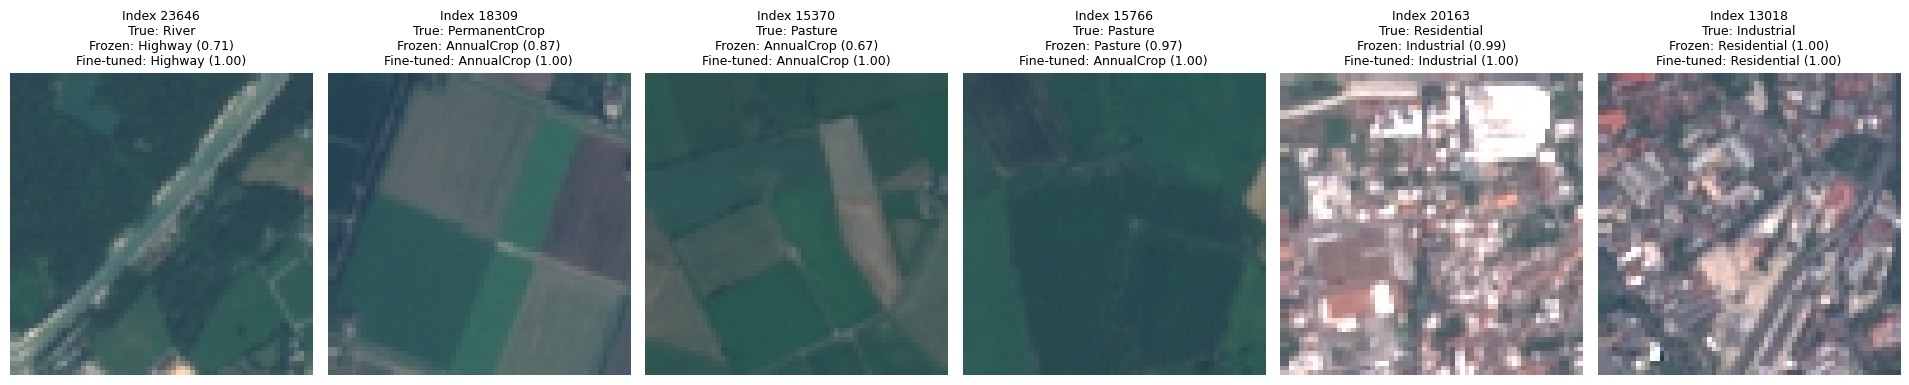

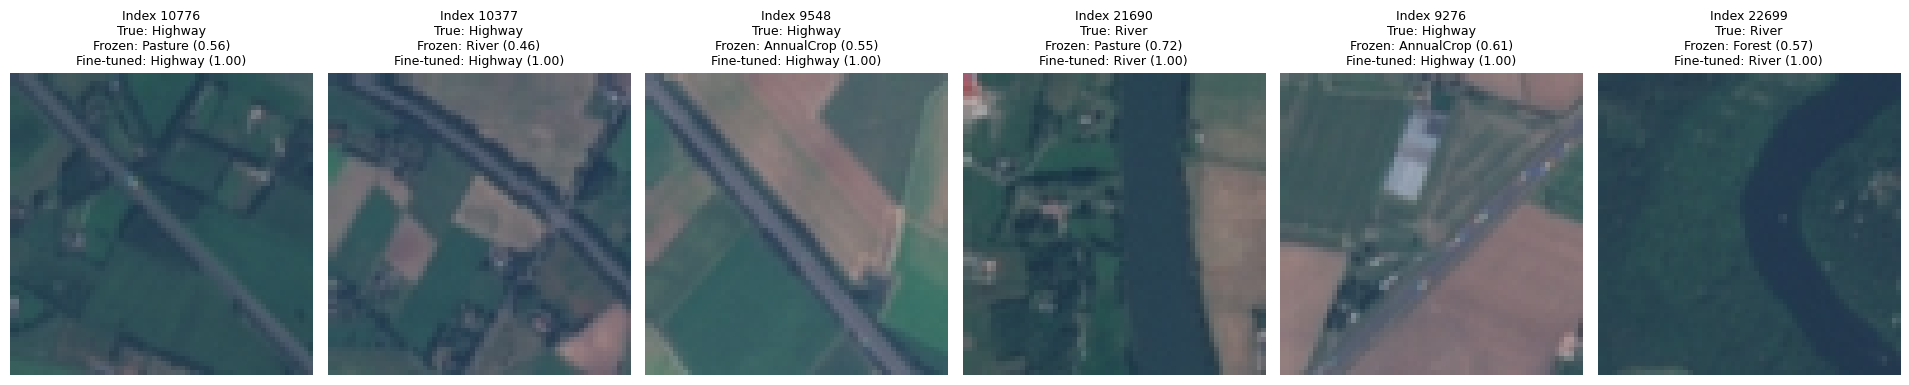

In [5]:
remaining = cases[~cases["dataset_index"].isin(STARTER_IDS)]

confident_errors = (
    remaining.loc[remaining["fine_tuned_error"]]
    .sort_values("fine_tuned_confidence", ascending=False)
    .head(6)
)

confident_corrections = (
    remaining.loc[
        remaining["comparison_category"] == "corrected_by_fine_tuning"
    ]
    .sort_values("fine_tuned_confidence", ascending=False)
    .head(6)
)

display(confident_errors[
    ["dataset_index", "class_name", "frozen_prediction",
     "fine_tuned_prediction", "fine_tuned_confidence"]
])

display(confident_corrections[
    ["dataset_index", "class_name", "frozen_prediction",
     "fine_tuned_prediction", "fine_tuned_confidence"]
])

show_cases(
    confident_errors["dataset_index"].tolist(),
    "confident_fine_tuned_errors.png",
)
show_cases(
    confident_corrections["dataset_index"].tolist(),
    "confident_corrections.png",
)

## Record image-level observations

The notes sheet separates **visible features** from **possible explanations**. Record uncertainty or apparent label ambiguity without silently relabeling an image. An existing `case_notes.csv` is preserved when the cell is rerun.


In [6]:
notes_path = OUTPUT / "case_notes.csv"

if notes_path.exists():
    notes = pd.read_csv(notes_path).fillna("")
    print("Existing notes preserved:", notes_path)
else:
    selected_ids = list(dict.fromkeys(
        STARTER_IDS
        + confident_errors["dataset_index"].tolist()
        + confident_corrections["dataset_index"].tolist()
    ))

    notes = (
        cases.set_index("dataset_index")
        .loc[selected_ids]
        .reset_index()
        [[
            "dataset_index", "relative_path", "class_name",
            "frozen_prediction", "frozen_confidence",
            "fine_tuned_prediction", "fine_tuned_confidence",
            "comparison_category",
        ]]
    )

    notes["visible_features"] = ""
    notes["possible_reason_for_confusion"] = ""
    notes["label_ambiguity_or_image_quality"] = ""
    notes["confidence_in_interpretation"] = ""

    notes.to_csv(notes_path, index=False)
    print("Created:", notes_path)

display(notes)

Created: C:\Users\comviva\Documents\Eurosat_calibrated\results\qualitative_failure_analysis\case_notes.csv


,dataset_index,relative_path,class_name,frozen_prediction,frozen_confidence,fine_tuned_prediction,fine_tuned_confidence,comparison_category,visible_features,possible_reason_for_confusion,label_ambiguity_or_image_quality,confidence_in_interpretation
0,17607,eurosat/2750/PermanentCrop/PermanentCrop_2445.jpg,PermanentCrop,AnnualCrop,0.698881,PermanentCrop,0.999997,corrected_by_fine_tuning,,,,
1,17570,eurosat/2750/PermanentCrop/PermanentCrop_2411.jpg,PermanentCrop,PermanentCrop,0.526528,HerbaceousVegetation,0.983009,new_error_after_fine_tuning,,,,
2,23294,eurosat/2750/River/River_363.jpg,River,Highway,0.531072,River,0.999713,corrected_by_fine_tuning,,,,
3,23106,eurosat/2750/River/River_2444.jpg,River,Highway,0.934705,Highway,0.999658,both_wrong,,,,
4,10259,eurosat/2750/Highway/Highway_2131.jpg,Highway,River,0.946476,Highway,0.650208,corrected_by_fine_tuning,,,,
5,11308,eurosat/2750/Highway/Highway_826.jpg,Highway,River,0.672065,River,0.757063,both_wrong,,,,
6,23646,eurosat/2750/River/River_680.jpg,River,Highway,0.711661,Highway,1.000000,both_wrong,,,,
7,18309,eurosat/2750/PermanentCrop/PermanentCrop_827.jpg,PermanentCrop,AnnualCrop,0.870848,AnnualCrop,0.999823,both_wrong,,,,
8,15370,eurosat/2750/Pasture/Pasture_431.jpg,Pasture,AnnualCrop,0.667235,AnnualCrop,0.999692,both_wrong,,,,
9,15766,eurosat/2750/Pasture/Pasture_789.jpg,Pasture,Pasture,0.968876,AnnualCrop,0.999533,new_error_after_fine_tuning,,,,


## Preliminary findings and interpretation

- The fine-tuned ResNet18 makes **83 errors** on 4,050 test images. The largest class error counts are PermanentCrop (21 of 375), Pasture (16 of 300), HerbaceousVegetation (13 of 450), and River (11 of 375). Forest and SeaLake have no errors on this fixed test set.
- Frequent fine-tuned confusion pairs include PermanentCrop → AnnualCrop (11 images), Pasture → AnnualCrop (7), PermanentCrop → HerbaceousVegetation (6), and River → Highway (5). Highway → River occurs twice. These counts are from all test predictions, beyond the examples displayed above.
- Fine-tuning corrects **152** errors made by frozen ResNet18 but introduces **30** errors on images that the frozen model classified correctly. Both models are wrong on **53** images. The galleries show examples of these categories and should be discussed as examples, not as evidence of a single mechanism.
- Some displayed patches contain field-like patterns or narrow linear features that may make crop classes or River and Highway visually confusable at 64 × 64 resolution. This is a **visual hypothesis** from selected RGB patches, not a demonstrated cause of any model decision. Top-label confidence does not establish that a prediction or a manifest label is correct.


